## Housing Price Prediction & Property Segmentation

**Project Overview**  
Develop a predictive model to estimate residential housing prices and identify property segments based on structural characteristics.

**Approach**  
- Cleaned and imputed missing numeric and categorical features  
- Performed exploratory data analysis (EDA) and correlation analysis  
- Built and evaluated a Linear Regression model using R² and Adjusted R²  
- Applied K-Means clustering to segment properties by lot size and build year  
- Integrated cluster insights back into regression modeling

**Key Results**  
- Linear regression explains ~79–82% of price variance on unseen data  
- Model generalizes well with minimal overfitting  
- Property clusters capture meaningful differences in housing characteristics

**Tools**  
Python, Pandas, NumPy, Scikit-learn, Matplotlib, Seaborn


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("WestRoxbury_housing.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5802 entries, 0 to 5801
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   TOTAL VALUE  5802 non-null   float64
 1   LOT SQFT     5684 non-null   float64
 2   YR BUILT     5739 non-null   float64
 3   GROSS AREA   5802 non-null   int64  
 4   LIVING AREA  5802 non-null   int64  
 5   FLOORS       5802 non-null   float64
 6   ROOMS        5802 non-null   int64  
 7   BEDROOMS     5802 non-null   int64  
 8   FULL BATH    5802 non-null   int64  
 9   HALF BATH    5802 non-null   int64  
 10  KITCHEN      5802 non-null   int64  
 11  FIREPLACE    5802 non-null   int64  
 12  REMODEL      1444 non-null   object 
dtypes: float64(4), int64(8), object(1)
memory usage: 589.4+ KB


In [2]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
numeric_columns

['TOTAL VALUE',
 'LOT SQFT',
 'YR BUILT',
 'GROSS AREA',
 'LIVING AREA',
 'FLOORS',
 'ROOMS',
 'BEDROOMS',
 'FULL BATH',
 'HALF BATH',
 'KITCHEN',
 'FIREPLACE']

In [3]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()
#numeric_columns

medianFiller = lambda x: x.fillna(x.median())
df[numeric_columns] = df[numeric_columns].apply(medianFiller, axis=0)
df.isnull().sum()

categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

# x.mode() returns a Series, not a single value. caused below to fail
# fillna() fill missing values with an entire Series, not a single value — which causes a shape mismatch or silently fails to fill properly.
#modeFiller = lambda x: x.fillna(x.mode())

#df[categorical_columns] = df[categorical_columns].apply(modeFiller, axis=0)

#df['categorical_columns'] = df['categorical_columns'].fillna(df['categorical_columns'].mode()[0], inplace=True)
#df.isnull().sum()
for col in categorical_columns:
    df[col].fillna(df[col].mode()[0])

#df.isnull().sum()

In [4]:
duplicate_rows = df[df.duplicated(keep=False)]
print("\nActual duplicate rows:")
print(duplicate_rows)

df_cleaned = df.drop_duplicates()



Actual duplicate rows:
      TOTAL VALUE  LOT SQFT  YR BUILT  GROSS AREA  LIVING AREA  FLOORS  ROOMS  \
1139        564.8    6000.0    2005.0        4398         2543     2.0      8   
1178        564.8    6000.0    2005.0        4398         2543     2.0      8   
3886        582.8    6009.0    2004.0        3826         2341     2.0      7   
3894        582.8    6009.0    2004.0        3826         2341     2.0      7   
5224        620.4    5000.0    2004.0        4149         2516     2.0      7   
5227        620.4    5000.0    2004.0        4149         2516     2.0      7   

      BEDROOMS  FULL BATH  HALF BATH  KITCHEN  FIREPLACE REMODEL  
1139         4          2          2        1          1     NaN  
1178         4          2          2        1          1     NaN  
3886         4          2          1        1          1     NaN  
3894         4          2          1        1          1     NaN  
5224         4          3          1        1          2     NaN  
5227  

In [23]:
df_cleaned['YR BUILT'].describe()

count    5799.000000
mean     1936.678048
std        35.895742
min         0.000000
25%      1920.000000
50%      1935.000000
75%      1954.000000
max      2011.000000
Name: YR BUILT, dtype: float64

In [30]:
df_cleaned['YR BUILT'].sort_values().head(10)
#df['YR BUILT'].sort_values(ascending=False).head(10)

1492       0.0
523     1798.0
1600    1800.0
2831    1804.0
1844    1810.0
1860    1810.0
2835    1820.0
1727    1820.0
2541    1820.0
3321    1835.0
Name: YR BUILT, dtype: float64

In [5]:
abnormal = df[(df['YR BUILT'] < 1800) | (df['YR BUILT'] > 2025)]
abnormal

,TOTAL VALUE,LOT SQFT,YR BUILT,GROSS AREA,LIVING AREA,FLOORS,ROOMS,BEDROOMS,FULL BATH,HALF BATH,KITCHEN,FIREPLACE,REMODEL
523,437.9,8861.0,1798.0,5356,2953,2.0,11,4,2,0,1,0,Old
1492,569.2,7000.0,0.0,4732,2641,2.0,8,4,2,1,1,1,Recent


In [6]:
# “impute” (replace) missing/invalid data
# Replace invalid years with median
median_year = df_cleaned['YR BUILT'].median()
df_cleaned.loc[(df_cleaned['YR BUILT'] < 1800) | (df_cleaned['YR BUILT'] > 2025), 'YR BUILT'] = median_year

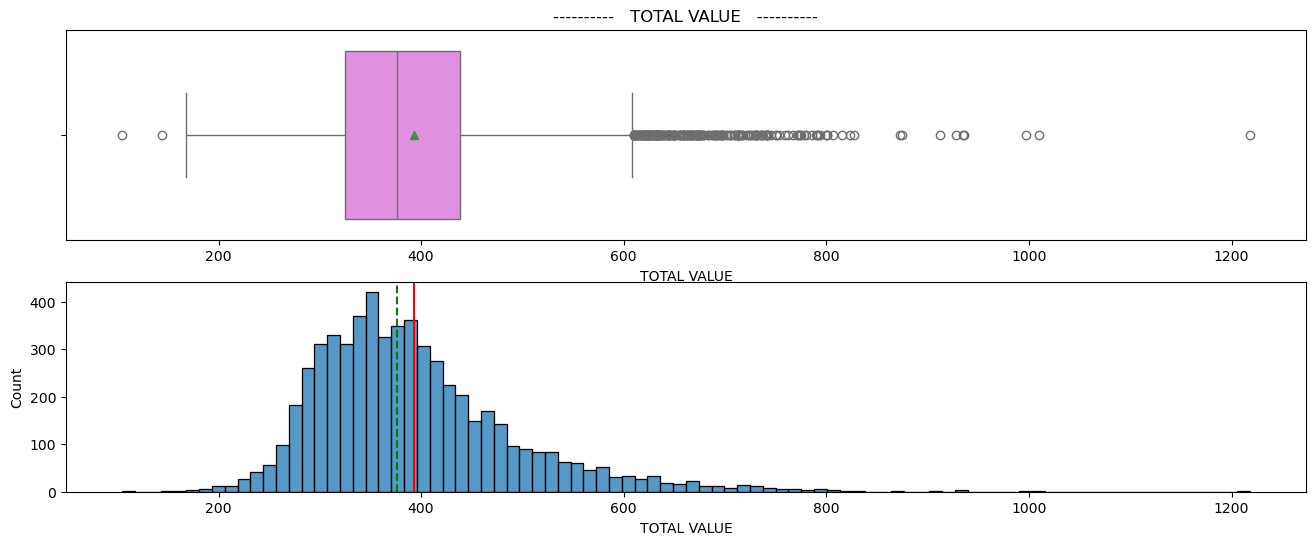

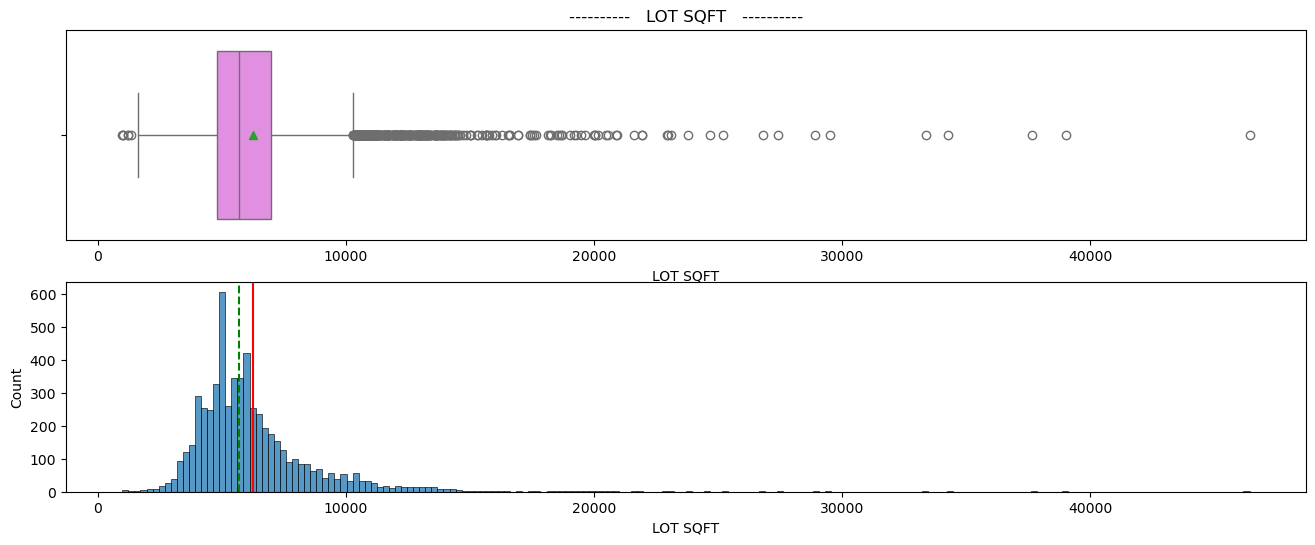

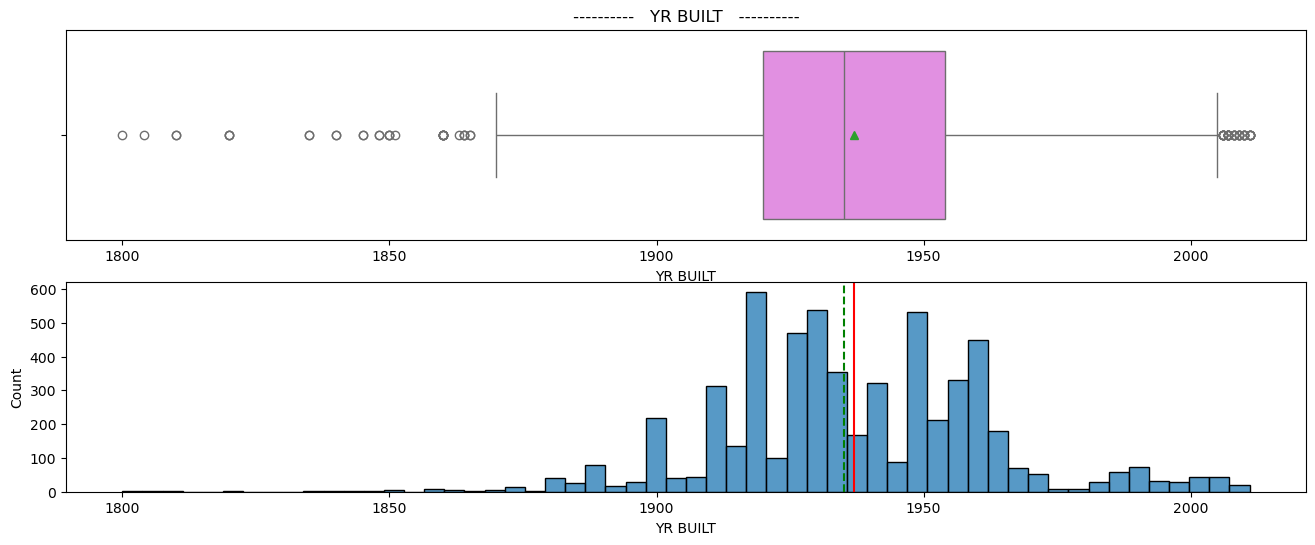

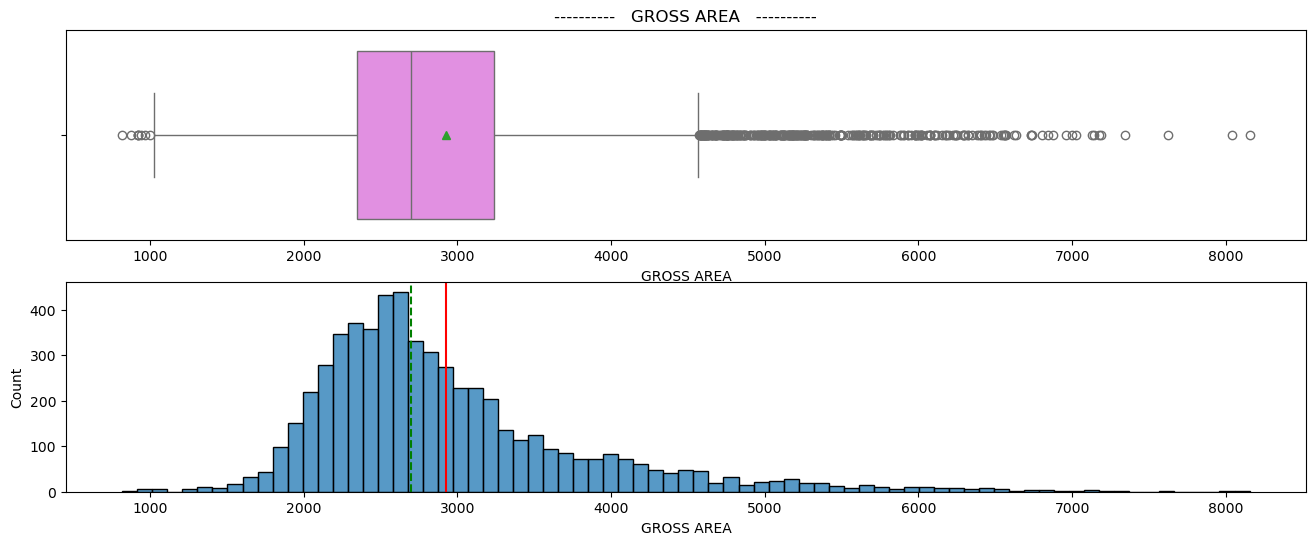

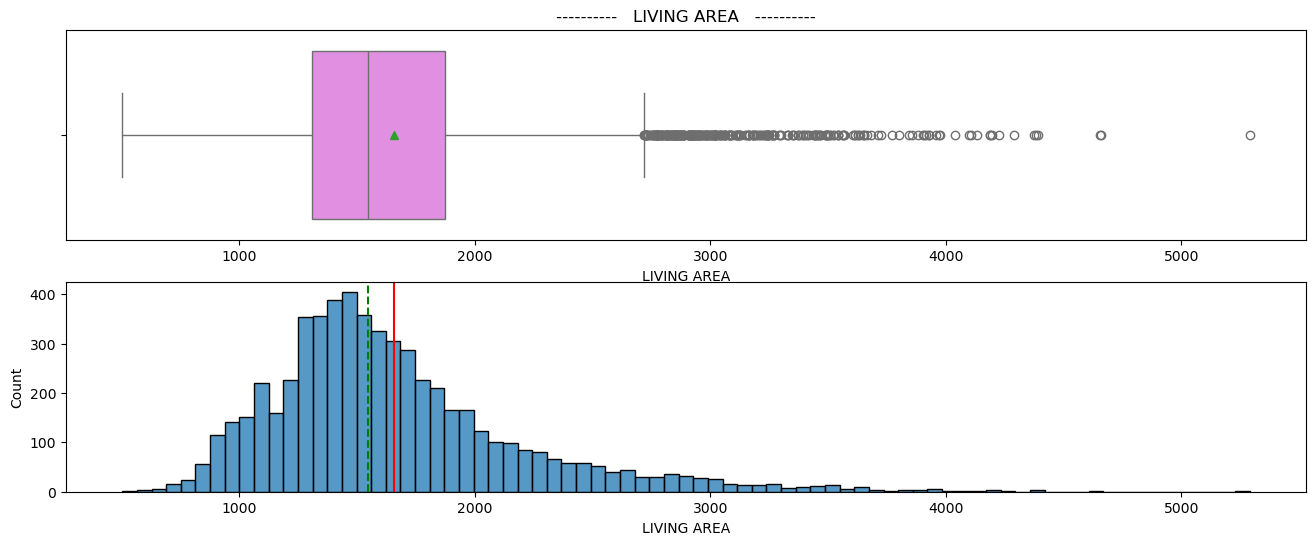

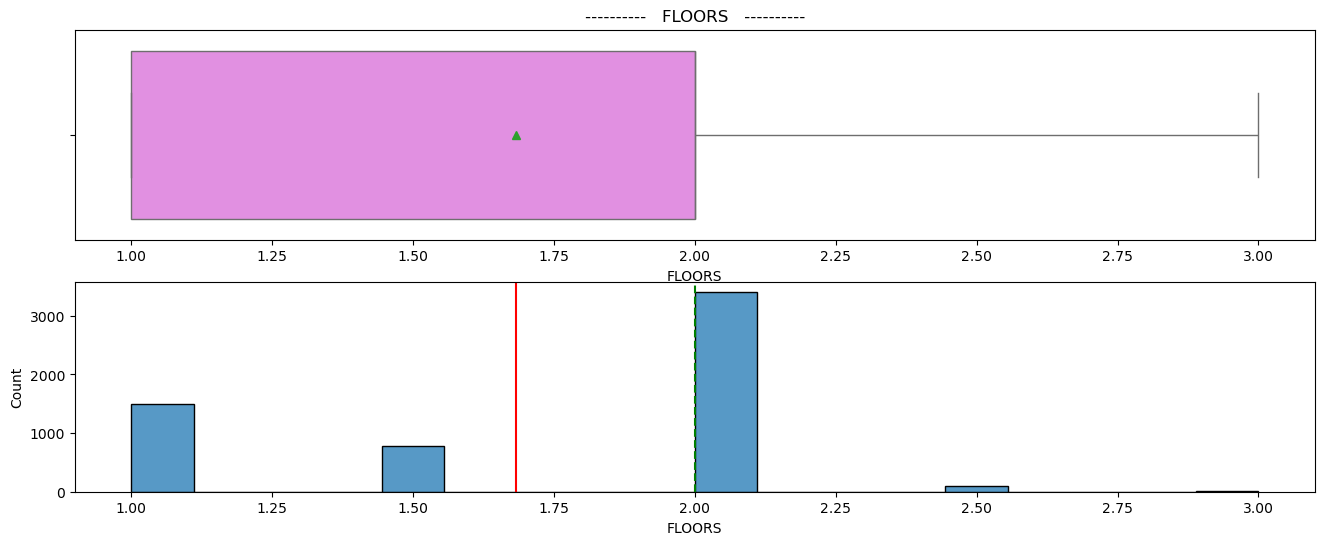

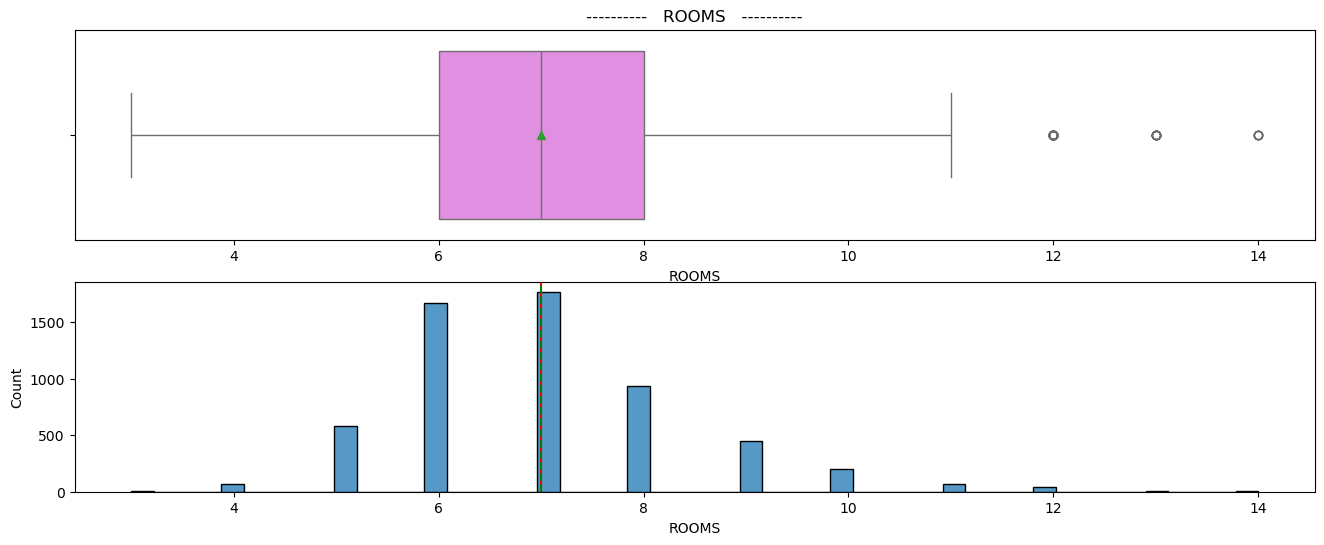

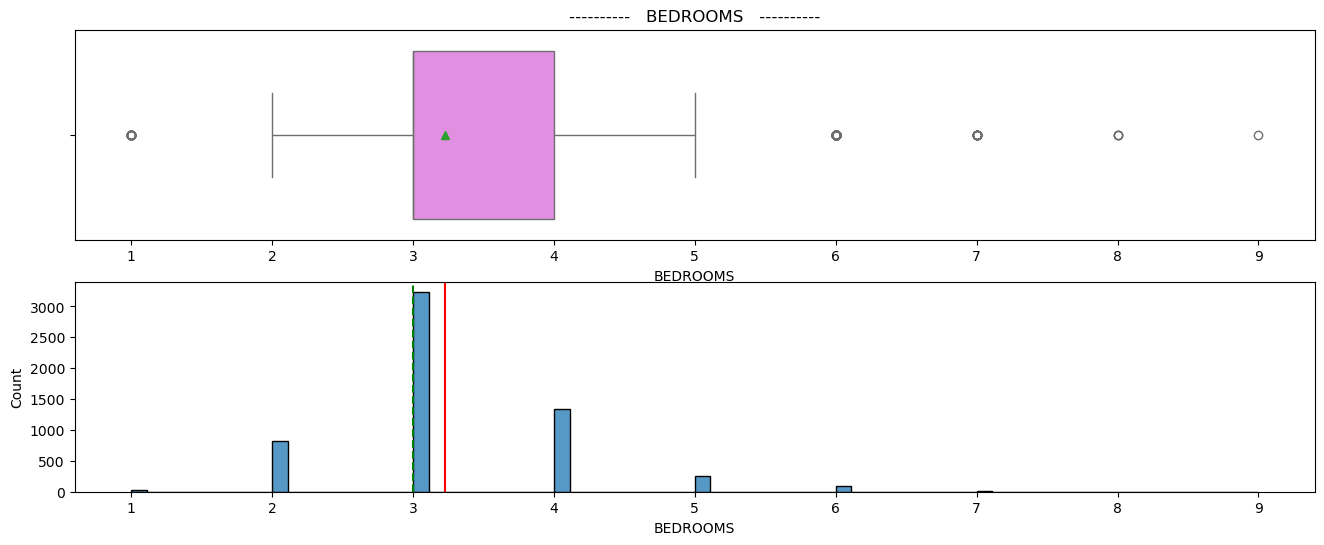

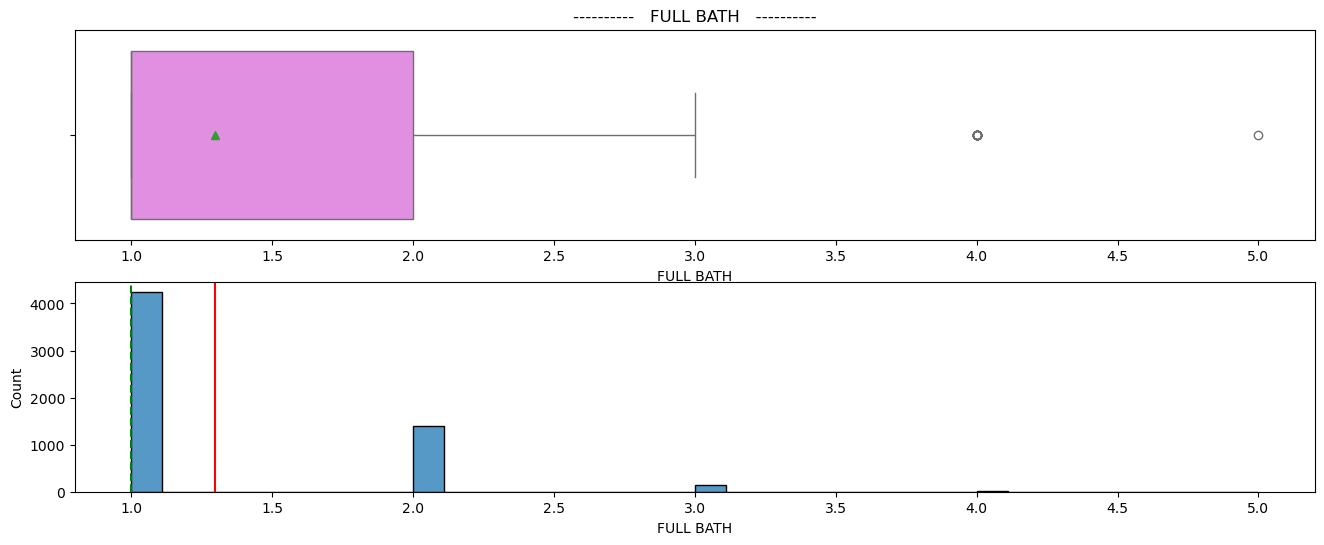

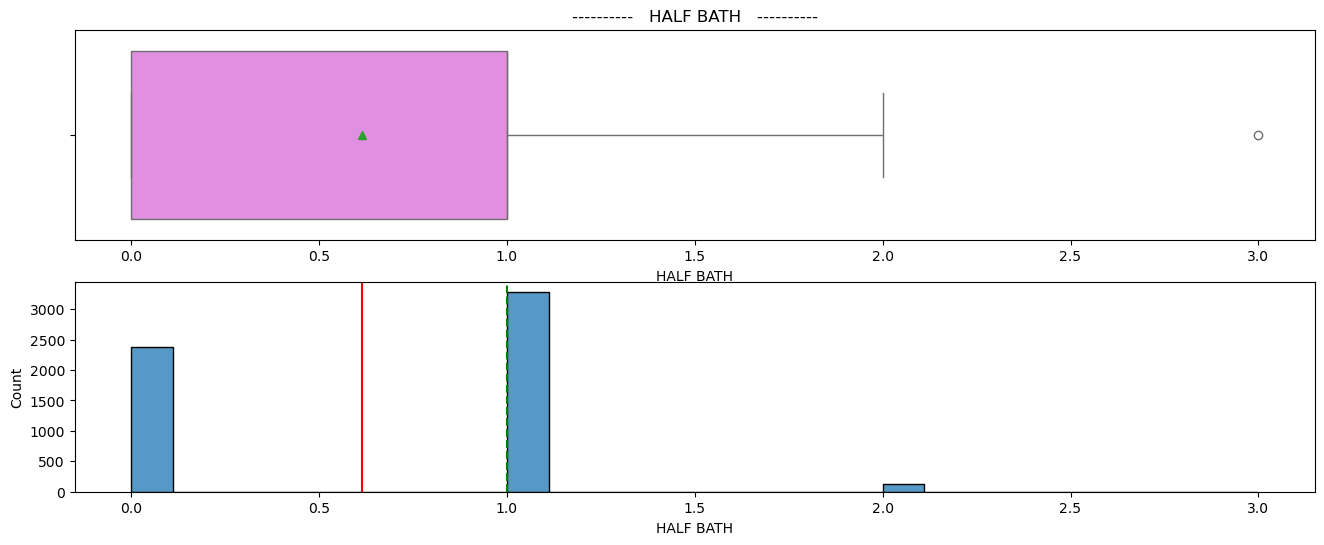

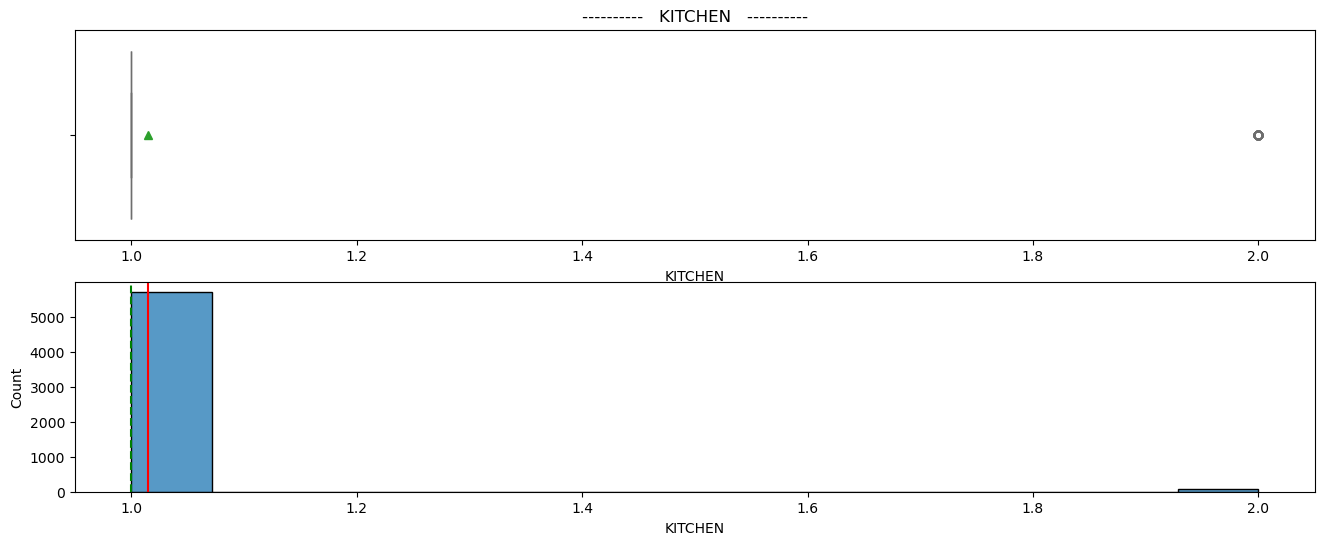

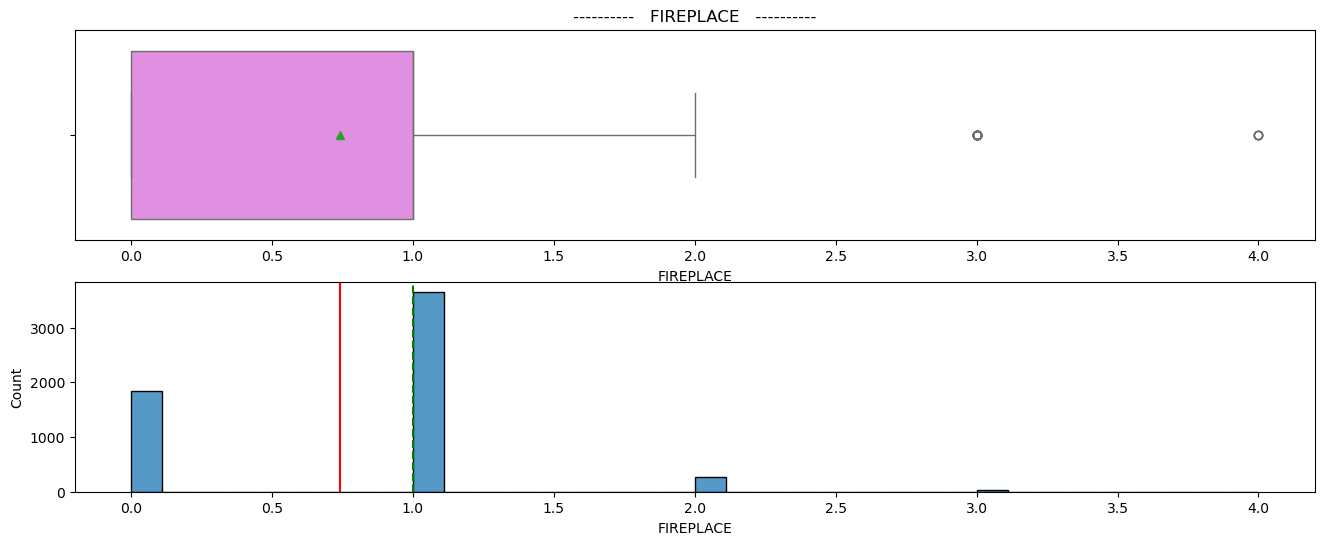

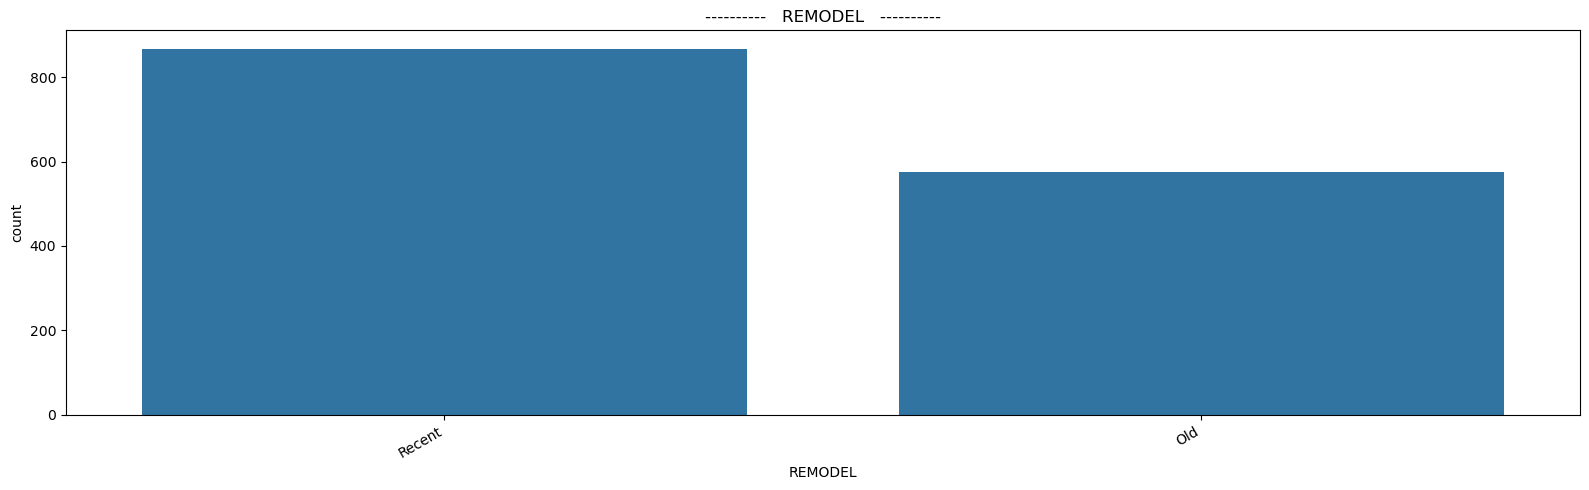

In [7]:
#univariate EDA
# --- numeric columns only ---
num_cols = df_cleaned.select_dtypes(include=[np.number]).columns

for col in num_cols:
    plt.figure(figsize=(16, 6)) # new figure window for each column. width = 16 inc, height = 6 inc. prevents all plots overlapping each other. 
    plt.subplot(2, 1, 1) #divides the figure into a grid of 2 rows × 1 column, select first plot area
    plt.title("----------   " + col + "   ----------") # show title for each columns in the df
    sns.boxplot(x=df_cleaned[col], showmeans=True, color="violet")
    
    plt.subplot(2, 1, 2) # Moves the focus to the second subplot in the same figure (2 rows, 1 column, second position
    #sns.histplot(data=df_cleaned, x=col) #Creates a histogram
    sns.histplot(x=df_cleaned[col], kde=False)
    plt.axvline(df_cleaned[col].mean(), color="red", linestyle="-") # draws a vertical line (mean) in red line on the histogram
    plt.axvline(df_cleaned[col].median(), color="green", linestyle="--") # draws a vertical line (median) in red line on the histogram
    plt.show()

# --- categorical columns: use countplot (no mean/median) ---
cat_cols = df_cleaned.select_dtypes(exclude=[np.number]).columns

for col in cat_cols:
    plt.figure(figsize=(16, 5))
    plt.title(f"----------   {col}   ----------")
    sns.countplot(x=df_cleaned[col])
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()    

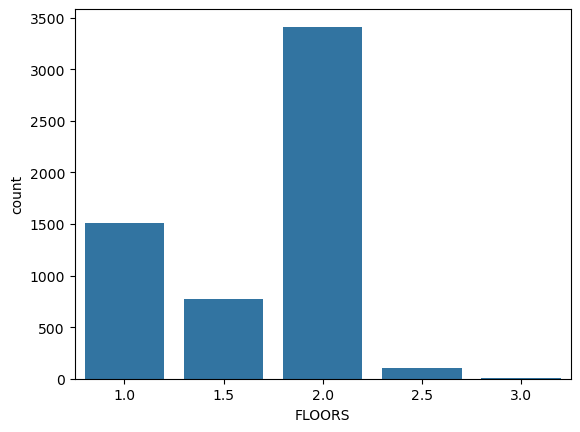

In [55]:
sns.countplot(data=df_cleaned, x="FLOORS")
plt.show()

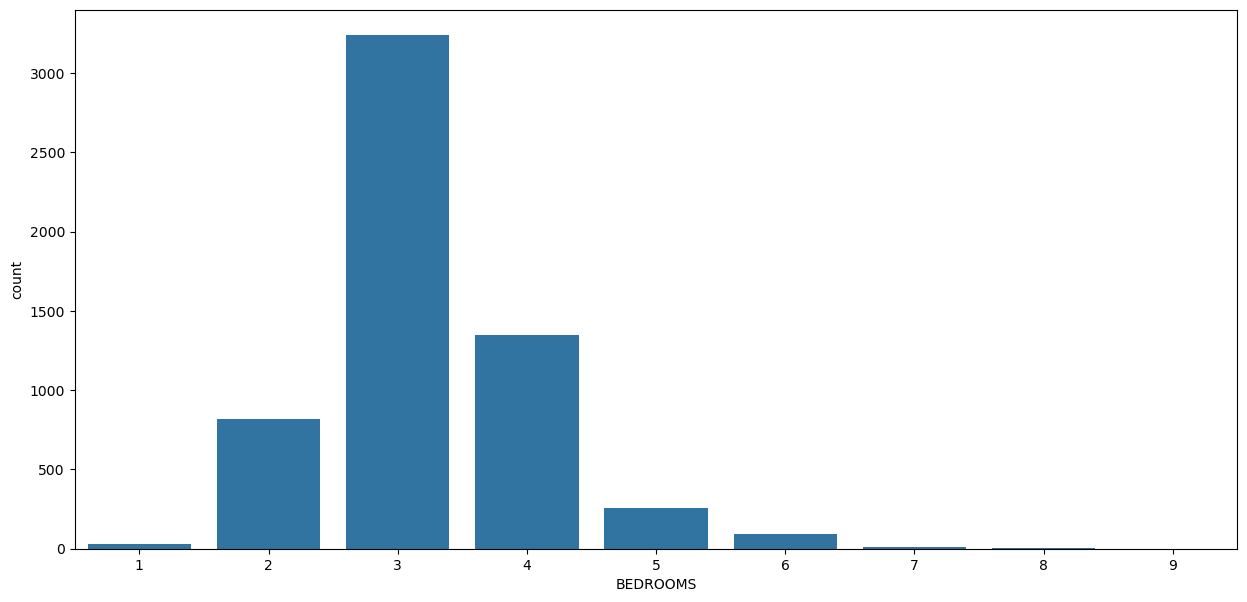

In [57]:
plt.figure(figsize=(15, 7))
sns.countplot(data=df, x="BEDROOMS")
plt.show()

In [59]:
# Computes pairwise Pearson correlation between all numeric columns.
df_cleaned[num_cols].corr()["TOTAL VALUE"]

TOTAL VALUE    1.000000
LOT SQFT       0.541636
YR BUILT      -0.120628
GROSS AREA     0.800356
LIVING AREA    0.836937
FLOORS         0.481353
ROOMS          0.639013
BEDROOMS       0.561638
FULL BATH      0.431643
HALF BATH      0.347456
KITCHEN        0.018412
FIREPLACE      0.357930
Name: TOTAL VALUE, dtype: float64

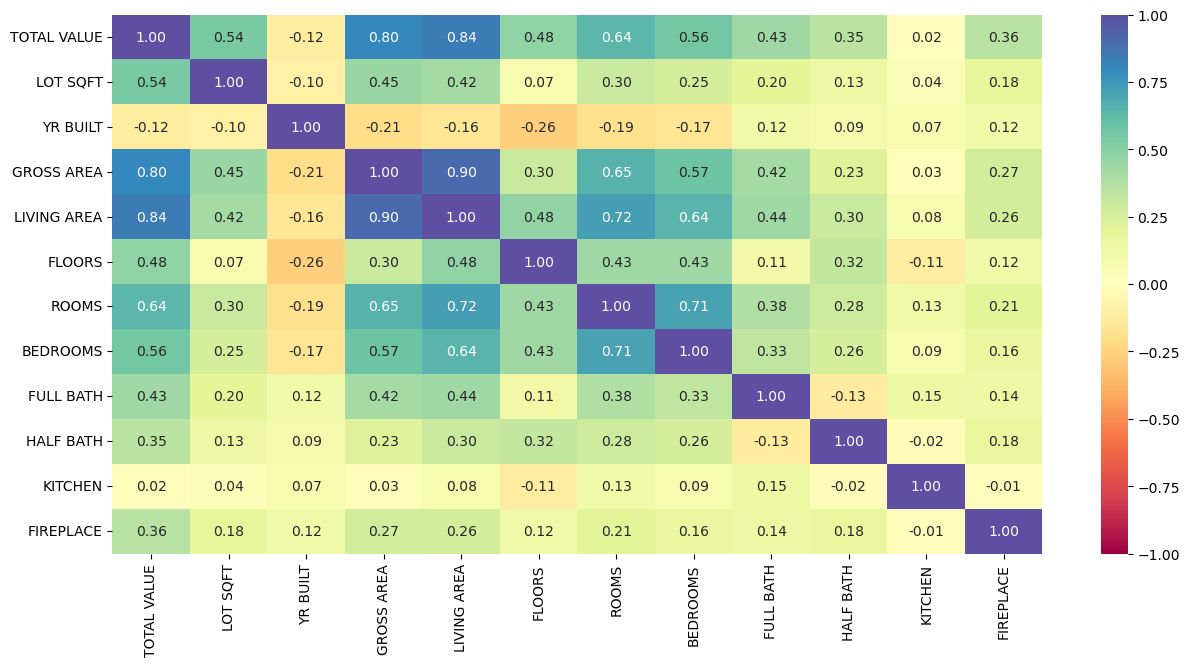

In [60]:
# correlation heatmap
plt.figure(figsize=(15, 7))
sns.heatmap(df_cleaned[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
X = df_cleaned.drop('TOTAL VALUE', axis=1)
Y = df_cleaned['TOTAL VALUE']

# Splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [9]:
# one-hot separately on train and test
X_train_enc = pd.get_dummies(X_train, columns=['REMODEL'], drop_first=False)
X_test_enc  = pd.get_dummies(X_test,  columns=['REMODEL'], drop_first=False)

# align columns so they match exactly (fill missing dummies with 0)
X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join='outer', axis=1, fill_value=0)


In [10]:
# Define final features and target
X_train_final = X_train_enc.copy()
X_test_final  = X_test_enc.copy()
y_train_final = y_train.copy()
y_test_final  = y_test.copy()

In [13]:
from sklearn.linear_model import LinearRegression

# Initialize model
lr_model = LinearRegression()

# Fit on training data
lr_model.fit(X_train_final, y_train_final)

#Make predictions on the testing data
y_pred = lr_model.predict(X_test_final)

In [15]:
from sklearn.metrics import r2_score
y_pred_train = lr_model.predict(X_train_final)
y_pred_test  = y_pred

r2_train = r2_score(y_train_final, y_pred_train)
r2_test  = r2_score(y_test_final,  y_pred_test)

def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

adj_r2_train = adjusted_r2(r2_train, n=len(X_train_final), p=X_train_final.shape[1])
adj_r2_test  = adjusted_r2(r2_test,  n=len(X_test_final),  p=X_test_final.shape[1])

print(f"Train R²: {r2_train:.4f} | Adjusted R²: {adj_r2_train:.4f}")
print(f"Test  R²: {r2_test:.4f} | Adjusted R²: {adj_r2_test:.4f}")

Train R²: 0.8212 | Adjusted R²: 0.8207
Test  R²: 0.7913 | Adjusted R²: 0.7898


In [16]:
print("Interpretation:")
print("The R-squared values indicate how well the model explains the variation in TOTAL VALUE.")
print("Training R² = 0.8212 means the model explains about 82% of price variation in the training data.")
print("Testing R² = 0.7913 means the model explains about 79% of variation in unseen data.")
print("Since both are close, the model generalizes well without overfitting.")

Interpretation:
The R-squared values indicate how well the model explains the variation in TOTAL VALUE.
Training R² = 0.8212 means the model explains about 82% of price variation in the training data.
Testing R² = 0.7913 means the model explains about 79% of variation in unseen data.
Since both are close, the model generalizes well without overfitting.


In [17]:
coef_df = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Coefficient': lr_model.coef_
}).sort_values(by='Coefficient', ascending=False)

# Display top 10 largest coefficients
coef_df.head(10)

,Feature,Coefficient
4,FLOORS,43.391369
12,REMODEL_Recent,24.798175
7,FULL BATH,18.662672
10,FIREPLACE,18.099571
8,HALF BATH,16.374537
11,REMODEL_Old,5.069368
5,ROOMS,1.478482
1,YR BUILT,0.193383
3,LIVING AREA,0.048622
2,GROSS AREA,0.032982


In [18]:
print('FLOORS (43.39): Each additional floor increases a home’s value by about 43 units, meaning multi-story houses tend to be worth more.')

print('REMODEL_Recent (24.79): Recently remodeled homes are valued roughly 25 units higher than those not remodeled, showing renovations boost property value.')

print('FULL BATH (18.66): Each extra full bathroom adds around 19 units to the total value, reflecting higher comfort and desirability.')

FLOORS (43.39): Each additional floor increases a home’s value by about 43 units, meaning multi-story houses tend to be worth more.
REMODEL_Recent (24.80): Recently remodeled homes are valued roughly 25 units higher than those not remodeled, showing renovations boost property value.
FULL BATH (18.66): Each extra full bathroom adds around 19 units to the total value, reflecting higher comfort and desirability.


In [21]:
# to scale the data using z-score
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Select features for clustering
X_cluster_train = X_train_final[['LOT SQFT', 'YR BUILT']].copy()
X_cluster_test  = X_test_final[['LOT SQFT', 'YR BUILT']].copy()

# Initialize the scaler
scaler = StandardScaler()

# Fit on training set only (to avoid data leakage)
scaler.fit(X_cluster_train)

# Transform both training and test sets
X_cluster_train_scaled = scaler.transform(X_cluster_train)
X_cluster_test_scaled  = scaler.transform(X_cluster_test)

#pd.DataFrame(X_cluster_train_scaled, columns=['LOT SQFT_scaled', 'YR BUILT_scaled']).head()

,LOT SQFT_scaled,YR BUILT_scaled
0,-0.481849,0.130534
1,-0.482966,-0.461375
2,-0.576013,-0.303532
3,-1.497181,-1.645191
4,-0.185214,0.130534


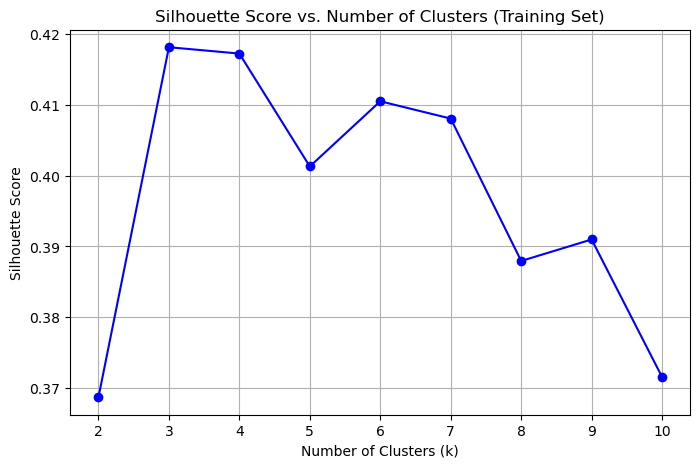

Optimal number of clusters (k) based on silhouette score: 3


In [22]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

k_values = range(2, 11)

silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_train_scaled)
    labels = kmeans.labels_
    score = silhouette_score(X_cluster_train_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(k_values, silhouette_scores, marker='o', color='blue')
plt.title('Silhouette Score vs. Number of Clusters (Training Set)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

best_k = k_values[silhouette_scores.index(max(silhouette_scores))]
print(f"Optimal number of clusters (k) based on silhouette score: {best_k}")


In [24]:
# Perform KMeans clustering using the optimal number of clusters
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)

# Fit on training data only
kmeans_final.fit(X_cluster_train_scaled)

# Predict cluster labels for both training and testing sets
train_clusters = kmeans_final.predict(X_cluster_train_scaled)
test_clusters = kmeans_final.predict(X_cluster_test_scaled)

# Assign the cluster labels as a new column in both training and testing sets
X_train_final['Cluster'] = train_clusters
X_test_final['Cluster'] = test_clusters


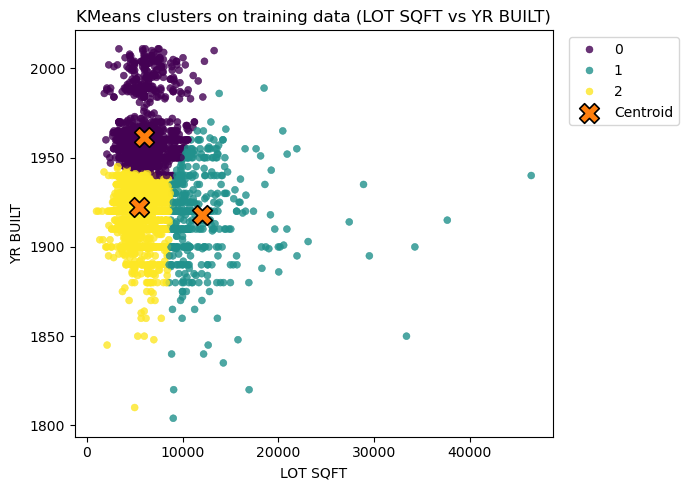

In [25]:
train_plot = pd.DataFrame({
    "LOT SQFT": X_train_final["LOT SQFT"],
    "YR BUILT": X_train_final["YR BUILT"],
    "Cluster":  X_train_final["Cluster"].astype(int)
})

centroids_scaled = kmeans_final.cluster_centers_
centroids_orig   = scaler.inverse_transform(centroids_scaled)
centroids_df = pd.DataFrame(centroids_orig, columns=["LOT SQFT", "YR BUILT"])
centroids_df["Cluster"] = range(len(centroids_df))

plt.figure(figsize=(7,5))
sns.scatterplot(
    data=train_plot, x="LOT SQFT", y="YR BUILT",
    hue="Cluster", palette="viridis", s=25, alpha=0.8, edgecolor=None
)
plt.scatter(
    centroids_df["LOT SQFT"], centroids_df["YR BUILT"],
    s=200, marker="X", linewidths=1.2, edgecolors="black", label="Centroid"
)
plt.title("KMeans clusters on training data (LOT SQFT vs YR BUILT)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [31]:
X_train_with_cluster = X_train_final.copy()
X_test_with_cluster = X_test_final.copy()

X_train_with_cluster['Cluster'] = X_train_final['Cluster']
X_test_with_cluster['Cluster'] = X_test_final['Cluster']


In [32]:
# One-hot encode the 'Cluster' column
X_train_enc2 = pd.get_dummies(X_train_with_cluster, columns=['Cluster'], drop_first=True)
X_test_enc2 = pd.get_dummies(X_test_with_cluster, columns=['Cluster'], drop_first=True)

# Align columns to ensure same structure between train and test sets
X_train_enc2, X_test_enc2 = X_train_enc2.align(X_test_enc2, join='outer', axis=1, fill_value=0)


In [33]:
from sklearn.linear_model import LinearRegression

# Initialize and train the model
lr_model_cluster = LinearRegression()
lr_model_cluster.fit(X_train_enc2, y_train_final)

# Predict
y_pred_train2 = lr_model_cluster.predict(X_train_enc2)
y_pred_test2 = lr_model_cluster.predict(X_test_enc2)


In [34]:
from sklearn.metrics import r2_score

# Function for Adjusted R²
def adjusted_r2(r2, n, p):
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

# Compute metrics
r2_train2 = r2_score(y_train_final, y_pred_train2)
r2_test2 = r2_score(y_test_final, y_pred_test2)

adj_r2_train2 = adjusted_r2(r2_train2, n=len(X_train_enc2), p=X_train_enc2.shape[1])
adj_r2_test2 = adjusted_r2(r2_test2, n=len(X_test_enc2), p=X_test_enc2.shape[1])

print(f"Train R²: {r2_train2:.4f} | Adjusted R²: {adj_r2_train2:.4f}")
print(f"Test  R²: {r2_test2:.4f} | Adjusted R²: {adj_r2_test2:.4f}")


Train R²: 0.8246 | Adjusted R²: 0.8239
Test  R²: 0.7944 | Adjusted R²: 0.7926


After including the Cluster feature, both R² and Adjusted R² values improved slightly for the training and testing datasets.
This indicates that the clusters provide additional information about the data structure (e.g., grouping similar houses by lot size and year built), which helps the model better explain the variation in house values.
Although the improvement is small, it suggests that the Cluster variable adds marginal predictive value and that the updated model performs slightly better than the previous one.